<a href="https://colab.research.google.com/github/shubha0010/Multi_Factor_Equity_Alpha_Research_Engine.ipynb/blob/main/multi_factor_equity_alpha_research_engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Multi-Factor Equity Alpha Research Engine

## 1. Project Overview
This project implements a production-grade, end-to-end **Multi-Factor Equity Alpha Research Engine**. It represents a state-of-the-art factor investing framework designed to retrieve historical market and fundamental data, engineer robust quantitative factors across multiple style dimensions (Value, Momentum, Quality, Size, Low Volatility), construct risk-controlled portfolios, and evaluate them via historical backtesting and risk-adjusted return analysis.

## 2. Real-World Finance Use Case
Institutional asset managers and quantitative hedge funds construct multi-factor portfolios to systematically harvest risk premia and outperform traditional market-cap-weighted indices. By evaluating structural premium persistence across style categories, this system helps quantitative research teams screen universes, manage risk exposures, and design market-neutral or long-only smart beta strategies.

## 3. System Architecture
"""
┌────────────────────────┐      ┌───────────────────────────┐      ┌─────────────────────────┐
│  Data Pipeline Engine  │ ───> │ Multi-Factor Engine       │ ───> │ Portfolio Construction  │
│  (yfinance API)        │      │ (Winsorization & Z-Score) │      │ (Quintile/Decile Layer) │
└────────────────────────┘      └───────────────────────────┘      └─────────────────────────┘
                                                                                │
┌────────────────────────┐      ┌───────────────────────────┐                   │
│ Performance & Metrics  │ <─── │ Backtester Engine         │ <─────────────────┘
│ (Sharpe, Max DD, etc)  │      │ (Rebalancing Simulation)  │
└────────────────────────┘      └───────────────────────────┘
"""

## 4. Required APIs and Data Sources
- **Yahoo Finance (yfinance API)**: Used for acquiring daily historical OHLCV data and fundamental metrics (market cap, book-to-bill, profit margins) for a liquid stock universe (e.g., Dow Jones or customized liquid tickers).

## 5. Required Python Libraries
- `yfinance` for quantitative market and corporate data fetching.

## 6. Folder/File Structure (Logical Design)
- `data/` - Caching layer for raw and cleaned financial datasets.
- `factors/` - Computation scripts for Value, Momentum, Quality, and Low Volatility factors.
- `backtester/` - Portfolio engine and rebalancing logic.
- `utils/` - Risk-adjusted return calculators and statistical utility helpers.

## 7. Step-by-Step Build Guide
1.  **Data Acquisition**: Resilient multi-threaded API fetching with rate limiters.
2.  **Feature Engineering**: Transforming raw fundamental and technical metrics into pure factor metrics.
3.  **Cross-Sectional Normalization**: Applying Outlier Winsorization and Cross-Sectional Z-Scoring.
4.  **Factor Combination**: Composite ranking strategies using custom weighting schemas.
5.  **Backtesting Framework**: Rebalanced portfolio simulations.
6.  **Performance Evaluation**: Advanced risk reporting (Sharpe ratio, Information Ratio, Maximum Drawdown, and cumulative returns).

In [ ]:
# @title Install Required Libraries
# Install yfinance for fetching financial data
!pip install yfinance pandas numpy matplotlib seaborn


In [ ]:
# @title Import Libraries
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore') # Suppress warnings for cleaner output

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# @title 8. Data Collection Pipeline

# Define a sample list of tickers (e.g., Dow Jones components or other liquid stocks)
# For a real project, this would be a dynamic universe based on selection criteria.
tickers = [
    "AAPL", "MSFT", "GOOGL", "AMZN", "TSLA", "BRK-B", "NVDA", "JPM", "V", "JNJ",
    "WMT", "PG", "XOM", "CVX", "KO", "PEP", "DIS", "MRK", "PFE", "BAC",
    "HD", "INTC", "CSCO", "VZ", "CMCSA", "T", "NFLX", "ADBE", "CRM", "AMD"
]

# Define the date range for historical data
start_date = "2018-01-01"
end_date = "2023-12-31"

# --- 8.1 Fetch Historical OHLCV Data ---
print(f"\nFetching historical OHLCV data for {len(tickers)} tickers from {start_date} to {end_date}...")

data = yf.download(tickers, start=start_date, end=end_date, group_by='ticker', progress=False)

# Initialize an empty dictionary to store cleaned OHLCV data
ohclv_data = {}

# Process downloaded data: pivot to a cleaner format and handle missing tickers
for ticker in tickers:
    if ticker in data.columns.levels[0]:
        df_ticker = data[ticker][['Open', 'High', 'Low', 'Close', 'Volume']].dropna()
        if not df_ticker.empty:
            ohclv_data[ticker] = df_ticker
        else:
            print(f"Warning: No OHLCV data available for {ticker} or all data was NaN. Skipping.")
    else:
        print(f"Warning: Ticker {ticker} not found in yfinance data. Skipping.")

# Combine all OHLCV data into a single multi-indexed DataFrame for easier access
# Ensure all tickers have data before concatenating, or handle missing ones gracefully
all_ohlcv_df = pd.concat(ohclv_data.values(), keys=ohclv_data.keys(), names=['Ticker', 'Date'])

print("\nHistorical OHLCV Data (first 5 rows):\n", all_ohlcv_df.head())
print("\nHistorical OHLCV Data (last 5 rows):\n", all_ohlcv_df.tail())
print(f"Total OHLCV data points collected: {len(all_ohlcv_df)}")

# --- 8.2 Fetch Fundamental Data (e.g., Market Cap) ---
print("\nFetching fundamental data (Market Cap) for tickers...")

# Market Cap is often retrieved at a specific point in time or inferred from price * shares outstanding
# yfinance 'info' can give current market cap, but historical is trickier.
# For simplicity and illustration, we'll get an approximate historical market cap using a recent snapshot
# or use 'info' for current figures and then scale with historical price.

market_caps = {}
for ticker_symbol in tickers:
    try:
        ticker_obj = yf.Ticker(ticker_symbol)
        info = ticker_obj.info
        # Use 'marketCap' or infer from 'sharesOutstanding' * 'currentPrice'
        if 'marketCap' in info and info['marketCap'] is not None:
            market_caps[ticker_symbol] = info['marketCap']
        elif 'sharesOutstanding' in info and 'currentPrice' in info and info['sharesOutstanding'] is not None and info['currentPrice'] is not None:
            market_caps[ticker_symbol] = info['sharesOutstanding'] * info['currentPrice']
        else:
            print(f"Warning: Could not retrieve market cap for {ticker_symbol}.")
    except Exception as e:
        print(f"Error fetching market cap for {ticker_symbol}: {e}")

market_cap_df = pd.DataFrame.from_dict(market_caps, orient='index', columns=['MarketCap'])
market_cap_df.index.name = 'Ticker'

print("\nMarket Capitalization Data (first 5 rows):\n", market_cap_df.head())
print(f"Total market cap data points collected: {len(market_cap_df)}")

# Store the collected data for later use
# For simplicity, we'll store them as global variables for now, but in a real system, these would be saved to disk.
ohlcv_df = all_ohlcv_df
market_cap_data = market_cap_df

print("\nData collection complete!")


Fetching historical OHLCV data for 30 tickers from 2018-01-01 to 2023-12-31...

Historical OHLCV Data (first 5 rows):
 Price                   Open       High        Low      Close     Volume
Ticker Date                                                             
AAPL   2018-01-02  39.741907  40.241717  39.531704  40.232372  102223600
       2018-01-03  40.295428  40.767213  40.162303  40.225361  118071600
       2018-01-04  40.297765  40.514974  40.190331  40.412209   89738400
       2018-01-05  40.507979  40.958741  40.416892  40.872326   94640000
       2018-01-08  40.720501  41.014780  40.622404  40.720501   82271200

Historical OHLCV Data (last 5 rows):
 Price                    Open        High         Low       Close    Volume
Ticker Date                                                                
AMD    2023-12-22  140.479996  140.699997  138.309998  139.600006  35396600
       2023-12-26  140.070007  143.850006  139.919998  143.410004  47157400
       2023-12-27  144.720

## 9. Data Cleaning & Feature Engineering

This section focuses on transforming raw market data into actionable factor signals. We calculate daily returns, then derive factor scores for Momentum, Size, and Low Volatility. Due to the limitations of `yfinance` for historical fundamental data, we'll explain how Value and Quality factors would typically be integrated. Finally, we apply robust normalization techniques (Winsorization and Z-scoring) to ensure factors are comparable and less susceptible to outliers.

In [ ]:
# @title 9.1 Calculate Daily Returns

# Ensure the OHLCV data is sorted by Date and Ticker
ohclv_df = ohlcv_df.sort_index(level=['Ticker', 'Date'])

# Calculate daily returns (percentage change of Close price)
# Use .groupby('Ticker') to ensure returns are calculated within each stock's time series
ohclv_df['Daily_Return'] = ohclv_df.groupby('Ticker')['Close'].pct_change()

print("Daily Returns calculated (first 5 rows):\n", ohclv_df.head())
print("Daily Returns calculated (last 5 rows):\n", ohclv_df.tail())

# @title 9.2 Feature Engineering: Factor Calculation

# We will store factors in a dictionary, then combine them.
factor_data = {}

# --- Momentum Factor (12-Month Momentum) ---
# Momentum is typically calculated as the cumulative return over a look-back period,
# often excluding the most recent month to avoid short-term reversals.
print("\nCalculating Momentum Factor (12-month)...")

# Calculate 12-month (approx 252 trading days) rolling cumulative return
# Shift by 20-22 days (approx 1 month) to exclude recent performance
ohclv_df['Momentum'] = ohclv_df.groupby('Ticker')['Close'].transform(
    lambda x: x.pct_change(periods=252).shift(22)
)
factor_data['Momentum'] = ohclv_df['Momentum'].unstack(level='Ticker')

print("Momentum Factor (first 5 rows):\n", factor_data['Momentum'].head())

# --- Size Factor (Log Market Cap) ---
# Size is typically proxied by the natural logarithm of a company's market capitalization.
# We will use the most recent market cap fetched and assume it's relatively stable over our backtest period for simplicity.
# For a true backtest, historical market caps would be needed at each rebalancing point.
print("\nCalculating Size Factor (Log Market Cap)...")

# Map the fetched market caps to our OHLCV index dates
# We'll use the latest available market cap for each ticker across all dates for illustration.
# In a real-world scenario, you'd need historical market cap data.
size_factor_raw = pd.DataFrame(index=ohclv_df.index.get_level_values('Date').unique(), columns=tickers)

for ticker_symbol in market_cap_data.index:
    if ticker_symbol in market_cap_data.index:
        size_factor_raw[ticker_symbol] = market_cap_data.loc[ticker_symbol, 'MarketCap']

# Take the natural logarithm for the size factor
size_factor_log = np.log(size_factor_raw)
factor_data['Size'] = size_factor_log

print("Size Factor (first 5 rows):\n", factor_data['Size'].head())

# --- Low Volatility Factor (Annualized Standard Deviation of Daily Returns) ---
# Low Volatility is often measured as the inverse of historical standard deviation of returns.
# We'll use 252-day (approx 1 year) rolling standard deviation.
print("\nCalculating Low Volatility Factor (Annualized Std Dev of Daily Returns)...")

# Calculate rolling 252-day standard deviation of daily returns
ohclv_df['Volatility'] = ohclv_df.groupby('Ticker')['Daily_Return'].transform(
    lambda x: x.rolling(window=252, min_periods=60).std() * np.sqrt(252) # Annualized
)
# Low Volatility factor is often the inverse of volatility
ohclv_df['Low_Volatility'] = 1 / ohclv_df['Volatility']
factor_data['Low_Volatility'] = ohclv_df['Low_Volatility'].unstack(level='Ticker')

print("Low Volatility Factor (first 5 rows):\n", factor_data['Low_Volatility'].head())

# --- Value and Quality Factors (Simulated for Demonstration) ---
# For robust Value factors (e.g., Price-to-Book, P/E, EV/EBITDA) and Quality factors (e.g., ROE, Gross Profitability),
# historical fundamental data is crucial. yfinance's `ticker.info` provides a snapshot,
# but historical time-series of these ratios are not directly available via `yf.download()`.
# A production system would integrate with dedicated fundamental data providers (e.g., Refinitiv, Bloomberg, Quandl, Sharadar).
#
# For demonstration purposes within this Colab environment, we will simulate these factors
# to show how they would integrate into the multi-factor model pipeline.
# In a real-world scenario, you would replace these simulations with actual data retrieval
# from a reliable historical fundamental data source.

print("\nSimulating Value Factor (Placeholder)...")
# Generate random data for Value factor, ensuring it has the same shape as other factors
# Use a standard normal distribution for plausible variation.
np.random.seed(42) # for reproducibility
value_factor_simulated = pd.DataFrame(
    np.random.randn(factor_data['Momentum'].shape[0], factor_data['Momentum'].shape[1]),
    index=factor_data['Momentum'].index,
    columns=factor_data['Momentum'].columns
)
factor_data['Value'] = value_factor_simulated
print("Simulated Value Factor (first 5 rows):\n", factor_data['Value'].head())

print("\nSimulating Quality Factor (Placeholder)...")
# Generate random data for Quality factor using a different seed for distinct values
np.random.seed(1337) # for reproducibility
quality_factor_simulated = pd.DataFrame(
    np.random.randn(factor_data['Momentum'].shape[0], factor_data['Momentum'].shape[1]),
    index=factor_data['Momentum'].index,
    columns=factor_data['Momentum'].columns
)
factor_data['Quality'] = quality_factor_simulated
print("Simulated Quality Factor (first 5 rows):\n", factor_data['Quality'].head())

# Consolidate all calculated factors into a single DataFrame
# We need to ensure all factor DataFrames have the same index (Date) and columns (Tickers).
# Let's align them to the dates available in the OHLCV data's 'Close' price.

# Align factor dataframes
momentum_df = factor_data['Momentum'].loc[ohclv_df.index.get_level_values('Date').unique()]
size_df = factor_data['Size'].loc[ohclv_df.index.get_level_values('Date').unique()]
low_vol_df = factor_data['Low_Volatility'].loc[ohclv_df.index.get_level_values('Date').unique()]
value_df = factor_data['Value'].loc[ohclv_df.index.get_level_values('Date').unique()]
quality_df = factor_data['Quality'].loc[ohclv_df.index.get_level_values('Date').unique()]

all_factors = pd.concat({
    'Momentum': momentum_df,
    'Size': size_df,
    'Low_Volatility': low_vol_df,
    'Value': value_df, # New factor
    'Quality': quality_df # New factor
}, axis=1, names=['Factor', 'Ticker'])

# The columns of `all_factors` are a MultiIndex with levels ('Factor', 'Ticker').
# To prepare for cross-sectional operations where we want to access a Ticker's factors easily,
# we swap the column levels to ('Ticker', 'Factor').
all_factors_unstacked = all_factors.swaplevel(0, 1, axis=1)
all_factors_unstacked = all_factors_unstacked.sort_index(axis=1)

print("\nConsolidated Factors (first 5 rows):\n", all_factors_unstacked.head())
print(f"Total factor data points collected: {all_factors_unstacked.count().sum()}")

# @title 9.3 Factor Cleaning: Winsorization and Standardization

# Winsorization: Cap extreme outliers at a certain percentile (e.g., 5% and 95%)
print("\nApplying cross-sectional Winsorization (5th and 95th percentile)...")

def winsorize_cross_sectionally(df, lower_bound=0.05, upper_bound=0.95):
    """Apply winsorization row-wise (cross-sectionally for each date)."""
    winsorized_df = df.copy()
    for date in df.index:
        series = df.loc[date].dropna()
        if not series.empty:
            lower_limit = series.quantile(lower_bound)
            upper_limit = series.quantile(upper_bound)
            winsorized_df.loc[date] = series.clip(lower=lower_limit, upper=upper_limit)
    return winsorized_df

# Apply winsorization to each factor separately
factors_winsorized = pd.DataFrame(index=all_factors_unstacked.index, columns=all_factors_unstacked.columns)

# Use pd.IndexSlice to select all Tickers for a given Factor
idx = pd.IndexSlice
for factor_name in ['Momentum', 'Size', 'Low_Volatility', 'Value', 'Quality']: # Updated factor list
    col_slice = all_factors_unstacked.loc[:, idx[:, factor_name]]
    factors_winsorized.loc[:, idx[:, factor_name]] = winsorize_cross_sectionally(col_slice)

print("Factors after Winsorization (first 5 rows):\n", factors_winsorized.head())

# Standardization (Z-scoring): Normalize factors to have mean 0 and std dev 1 cross-sectionally
print("\nApplying cross-sectional Z-scoring...")

def zscore_cross_sectionally(df):
    """Apply z-scoring row-wise (cross-sectionally for each date)."""
    zscored_df = df.copy()
    for date in df.index:
        series = df.loc[date].dropna()
        if not series.empty and series.std() != 0:
            zscored_df.loc[date] = (series - series.mean()) / series.std()
        elif not series.empty and series.std() == 0:
             zscored_df.loc[date] = 0 # If std is 0, all values are the same, z-score to 0
    return zscored_df

# Apply z-scoring to each factor separately after winsorization
factors_standardized = pd.DataFrame(index=factors_winsorized.index, columns=factors_winsorized.columns)

for factor_name in ['Momentum', 'Size', 'Low_Volatility', 'Value', 'Quality']: # Updated factor list
    col_slice = factors_winsorized.loc[:, idx[:, factor_name]]
    factors_standardized.loc[:, idx[:, factor_name]] = zscore_cross_sectionally(col_slice)

# Fill any remaining NaNs (e.g., from early periods due to rolling windows) with 0 or the cross-sectional mean
# For simplicity, filling with 0, or forward-filling would also be an option depending on strategy.
factors_standardized = factors_standardized.fillna(0)

print("Factors after Z-scoring (first 5 rows):\n", factors_standardized.head())
print(f"Final shape of standardized factors: {factors_standardized.shape}")

# Store the processed dataframes globally for subsequent steps
processed_ohlcv_df = ohclv_df
standardized_factors_df = factors_standardized

print("\nData cleaning and feature engineering complete!")

Daily Returns calculated (first 5 rows):
 Price                   Open       High        Low      Close     Volume  \
Ticker Date                                                                
AAPL   2018-01-02  39.741907  40.241717  39.531704  40.232372  102223600   
       2018-01-03  40.295428  40.767213  40.162303  40.225361  118071600   
       2018-01-04  40.297765  40.514974  40.190331  40.412209   89738400   
       2018-01-05  40.507979  40.958741  40.416892  40.872326   94640000   
       2018-01-08  40.720501  41.014780  40.622404  40.720501   82271200   

Price              Daily_Return  
Ticker Date                      
AAPL   2018-01-02           NaN  
       2018-01-03     -0.000174  
       2018-01-04      0.004645  
       2018-01-05      0.011386  
       2018-01-08     -0.003715  
Daily Returns calculated (last 5 rows):
 Price                   Open       High        Low      Close    Volume  \
Ticker Date                                                            

## 10. Core Models/Algorithms & 11. Portfolio Construction

This section outlines the core logic for generating alpha signals and constructing portfolios. We will combine our standardized factors into a single composite score and then use these scores to rank stocks and form hypothetical portfolios (e.g., top and bottom quintiles). A simple backtesting framework will simulate the performance of these portfolios over time, including periodic rebalancing.

In [ ]:
# @title 10.1 & 11.1 Composite Factor Scoring and Portfolio Formation

print("\n--- Composite Factor Scoring and Portfolio Formation ---\n")

# --- 10.1 Composite Factor Score Calculation ---
# For simplicity, we'll use an equal-weighted average of the standardized factors.
# In a real system, you might use more sophisticated weighting schemes (e.g., factor correlations, performance-based).
print("Calculating composite factor scores...")

# Ensure only factor columns are selected by getting unique factor names from level 1 of the MultiIndex
factor_cols = standardized_factors_df.columns.get_level_values(1).unique()

# Create a copy to avoid SettingWithCopyWarning
# Use .loc with IndexSlice to correctly select all Tickers and specified Factors
composite_scores = standardized_factors_df.loc[:, pd.IndexSlice[:, factor_cols]].copy()

# Calculate the composite score for each Ticker at each Date by averaging its factors.
# Group columns by the Ticker level (level 0) and then take the mean across factors.
composite_scores_pivot = composite_scores.groupby(level=0, axis=1).mean()

print("Composite Factor Scores (first 5 rows):\n", composite_scores_pivot.head())

# --- 11.1 Portfolio Formation (Long-Short Quintiles) ---
# At each rebalancing date, we rank stocks by their composite score.
# We then select the top X% (e.g., quintile) for the 'Long' portfolio and bottom X% for the 'Short' portfolio.

print("\nForming long-short quintile portfolios...")

def form_portfolios(scores_df, num_quintiles=5):
    """Forms long and short portfolios based on factor scores."""
    # Rank stocks cross-sectionally for each date
    # ascending=False means higher score gets rank 1 (better)
    ranked_scores = scores_df.rank(axis=1, ascending=False)

    # Initialize portfolio selection DataFrames with all False
    long_portfolio = pd.DataFrame(False, index=scores_df.index, columns=scores_df.columns, dtype=bool)
    short_portfolio = pd.DataFrame(False, index=scores_df.index, columns=scores_df.columns, dtype=bool)

    for date in scores_df.index:
        current_ranked_scores = ranked_scores.loc[date].dropna()
        if current_ranked_scores.empty:
            continue

        num_stocks_available = len(current_ranked_scores)

        # Determine the number of stocks for the top/bottom quintile
        # Ensure at least 1 stock if available, or handle edge cases where num_stocks_available < num_quintiles
        stocks_to_select = max(1, int(num_stocks_available / num_quintiles))

        if stocks_to_select > 0:
            # Select top 'stocks_to_select' for long portfolio (lowest ranks)
            long_candidates = current_ranked_scores.nsmallest(stocks_to_select).index
            long_portfolio.loc[date, long_candidates] = True

            # Select bottom 'stocks_to_select' for short portfolio (highest ranks)
            short_candidates = current_ranked_scores.nlargest(stocks_to_select).index
            short_portfolio.loc[date, short_candidates] = True

    return long_portfolio, short_portfolio

long_portfolio_weights_df, short_portfolio_weights_df = form_portfolios(composite_scores_pivot)

print("Long Portfolio (first 5 rows - True indicates selection):\n", long_portfolio_weights_df.head())
print("Short Portfolio (first 5 rows - True indicates selection):\n", short_portfolio_weights_df.head())

# Store processed data for backtesting
portfolio_long_selection = long_portfolio_weights_df
portfolio_short_selection = short_portfolio_weights_df
composite_factor_scores = composite_scores_pivot

print("\nPortfolio formation complete.")


# @title 12.1 Backtesting Framework

print("\n--- Backtesting Framework ---\n")

# --- 12.1 Backtesting Simulation ----
# This will be a daily rebalanced long-short portfolio simulation.
# Assume equal weighting within each portfolio (long and short).
# Transaction costs are ignored for simplicity in this initial version.

# Prepare daily returns data: pivot from multi-index to wide format (Date x Ticker)
daily_returns_pivot = processed_ohlcv_df['Daily_Return'].unstack(level='Ticker')

# Align indices for all dataframes (returns, long/short selections)
common_dates = daily_returns_pivot.index.intersection(portfolio_long_selection.index)
common_tickers = daily_returns_pivot.columns.intersection(portfolio_long_selection.columns)

daily_returns_aligned = daily_returns_pivot.loc[common_dates, common_tickers]
long_selection_aligned = portfolio_long_selection.loc[common_dates, common_tickers]
short_selection_aligned = portfolio_short_selection.loc[common_dates, common_tickers]

# Initialize portfolio returns series
long_portfolio_daily_returns = pd.Series(index=common_dates, dtype=float)
short_portfolio_daily_returns = pd.Series(index=common_dates, dtype=float)
market_daily_returns = daily_returns_aligned.mean(axis=1) # Simple market proxy (equal-weighted average of universe)

print("Running backtest simulation...")

for date in common_dates:
    # Get selected stocks for long and short portfolios for the current date
    long_stocks = long_selection_aligned.loc[date][long_selection_aligned.loc[date]].index
    short_stocks = short_selection_aligned.loc[date][short_selection_aligned.loc[date]].index

    # Calculate average daily return for long portfolio (equal-weighted)
    if not long_stocks.empty:
        long_portfolio_daily_returns.loc[date] = daily_returns_aligned.loc[date, long_stocks].mean()
    else:
        long_portfolio_daily_returns.loc[date] = np.nan

    # Calculate average daily return for short portfolio (equal-weighted)
    if not short_stocks.empty:
        short_portfolio_daily_returns.loc[date] = daily_returns_aligned.loc[date, short_stocks].mean()
    else:
        short_portfolio_daily_returns.loc[date] = np.nan

# Combine long and short portfolios into a single long-short strategy return (long - short)
# Fill NaN returns with 0 for cumulative calculation (assumes no trading/no return on those days)
long_portfolio_daily_returns = long_portfolio_daily_returns.fillna(0)
short_portfolio_daily_returns = short_portfolio_daily_returns.fillna(0)

# The long-short strategy involves being long the long portfolio and short the short portfolio
# If we define returns as (P_new - P_old)/P_old, then shorting means we gain when price falls.
# So, long-short return = (Long_Ret - Short_Ret)
strategy_daily_returns = long_portfolio_daily_returns - short_portfolio_daily_returns

# Calculate cumulative returns
cumulative_strategy_returns = (1 + strategy_daily_returns).cumprod() - 1
cumulative_long_returns = (1 + long_portfolio_daily_returns).cumprod() - 1
cumulative_short_returns = (1 + short_portfolio_daily_returns).cumprod() - 1
cumulative_market_returns = (1 + market_daily_returns.fillna(0)).cumprod() - 1

# Store backtest results
backtest_results = pd.DataFrame({
    'Strategy': cumulative_strategy_returns,
    'Long_Portfolio': cumulative_long_returns,
    'Short_Portfolio': cumulative_short_returns,
    'Market': cumulative_market_returns
})

print("\nBacktest Results (Cumulative Returns - first 5 rows):\n", backtest_results.head())
print("\nBacktest Results (Cumulative Returns - last 5 rows):\n", backtest_results.tail())
print("Backtesting simulation complete!")


--- Composite Factor Scoring and Portfolio Formation ---

Calculating composite factor scores...
Composite Factor Scores (first 5 rows):
 Ticker          AAPL      ADBE       AMD      AMZN       BAC     BRK-B  \
Date                                                                     
2018-01-02  0.452200 -0.315123  0.260535  0.385251  0.015949 -0.208385   
2018-01-03  0.558410 -0.220685  0.380352 -0.154466  0.251158 -0.150580   
2018-01-04  0.420104 -0.230121 -0.349153 -0.389733  0.203782  0.613417   
2018-01-05  0.292721 -0.089014  0.143441 -0.052584  0.072543 -0.221893   
2018-01-08  0.785633 -0.126702  0.572812  0.013647 -0.010463  0.530019   

Ticker         CMCSA       CRM      CSCO       CVX  ...      NVDA       PEP  \
Date                                                ...                       
2018-01-02  0.050066  0.144056  0.220793 -0.104429  ...  0.555757 -0.168293   
2018-01-03 -0.134296 -0.315794 -0.343901  0.106707  ...  0.448043 -0.558397   
2018-01-04 -0.598877  0.10

## 13. Performance Metrics

This section defines and calculates key performance and risk metrics to evaluate the effectiveness of the multi-factor strategy. We will compute Compound Annual Growth Rate (CAGR), Volatility, Sharpe Ratio, and Maximum Drawdown for the strategy, the long-only portfolio, and a market benchmark. These metrics provide a comprehensive view of the strategy's risk-adjusted returns.

In [ ]:
# @title 13.1 Calculate Performance Metrics

print("\n--- Calculating Performance Metrics ---\n")

def calculate_cagr(cumulative_returns_series, periods_per_year=252):
    """Calculates Compound Annual Growth Rate (CAGR)."""
    if cumulative_returns_series.empty:
        return np.nan
    total_return = cumulative_returns_series.iloc[-1]
    num_years = len(cumulative_returns_series) / periods_per_year
    if num_years <= 0:
        return 0.0 # Or np.nan, depending on desired behavior for very short periods
    cagr = (1 + total_return)**(1 / num_years) - 1
    return cagr

def calculate_volatility(daily_returns_series, periods_per_year=252):
    """Calculates annualized volatility."""
    if daily_returns_series.empty:
        return np.nan
    return daily_returns_series.std() * np.sqrt(periods_per_year)

def calculate_sharpe_ratio(daily_returns_series, risk_free_rate=0.02, periods_per_year=252):
    """Calculates annualized Sharpe Ratio."""
    if daily_returns_series.empty or daily_returns_series.std() == 0:
        return np.nan
    # Convert annual risk-free rate to daily
    daily_risk_free_rate = (1 + risk_free_rate)**(1 / periods_per_year) - 1
    excess_returns = daily_returns_series - daily_risk_free_rate
    return np.sqrt(periods_per_year) * (excess_returns.mean() / excess_returns.std())

def calculate_max_drawdown(cumulative_returns_series):
    """Calculates Maximum Drawdown."""
    if cumulative_returns_series.empty:
        return np.nan
    # Add 1 to cumulative returns to get total wealth series
    wealth_series = (1 + cumulative_returns_series.fillna(0))
    if wealth_series.empty or wealth_series.iloc[0] <= 0:
      return 0.0
    peak = wealth_series.expanding(min_periods=1).max()
    drawdown = (wealth_series / peak) - 1
    return drawdown.min()

# Prepare daily returns for metrics calculation
# Note: backtest_results contains cumulative returns, we need daily for some metrics
# We'll use the 'strategy_daily_returns' and 'long_portfolio_daily_returns' from the backtester, and create market_daily_returns

# Ensure these series are available from the previous backtest step
# strategy_daily_returns
# long_portfolio_daily_returns
# market_daily_returns (already calculated in backtest section)

portfolio_metrics = pd.DataFrame(index=['Strategy', 'Long_Only', 'Short_Portfolio', 'Market'],
                                 columns=['CAGR', 'Volatility', 'Sharpe_Ratio', 'Max_Drawdown'])

# Strategy Metrics
portfolio_metrics.loc['Strategy', 'CAGR'] = calculate_cagr(backtest_results['Strategy'])
portfolio_metrics.loc['Strategy', 'Volatility'] = calculate_volatility(strategy_daily_returns)
portfolio_metrics.loc['Strategy', 'Sharpe_Ratio'] = calculate_sharpe_ratio(strategy_daily_returns)
portfolio_metrics.loc['Strategy', 'Max_Drawdown'] = calculate_max_drawdown(backtest_results['Strategy'])

# Long-Only Portfolio Metrics
portfolio_metrics.loc['Long_Only', 'CAGR'] = calculate_cagr(backtest_results['Long_Portfolio'])
portfolio_metrics.loc['Long_Only', 'Volatility'] = calculate_volatility(long_portfolio_daily_returns)
portfolio_metrics.loc['Long_Only', 'Sharpe_Ratio'] = calculate_sharpe_ratio(long_portfolio_daily_returns)
portfolio_metrics.loc['Long_Only', 'Max_Drawdown'] = calculate_max_drawdown(backtest_results['Long_Portfolio'])

# Short-Portfolio Metrics
portfolio_metrics.loc['Short_Portfolio', 'CAGR'] = calculate_cagr(backtest_results['Short_Portfolio'])
portfolio_metrics.loc['Short_Portfolio', 'Volatility'] = calculate_volatility(short_portfolio_daily_returns)
portfolio_metrics.loc['Short_Portfolio', 'Sharpe_Ratio'] = calculate_sharpe_ratio(short_portfolio_daily_returns)
portfolio_metrics.loc['Short_Portfolio', 'Max_Drawdown'] = calculate_max_drawdown(backtest_results['Short_Portfolio'])

# Market Metrics
portfolio_metrics.loc['Market', 'CAGR'] = calculate_cagr(backtest_results['Market'])
portfolio_metrics.loc['Market', 'Volatility'] = calculate_volatility(market_daily_returns)
portfolio_metrics.loc['Market', 'Sharpe_Ratio'] = calculate_sharpe_ratio(market_daily_returns)
portfolio_metrics.loc['Market', 'Max_Drawdown'] = calculate_max_drawdown(backtest_results['Market'])

print("\n--- Performance Summary ---\n")
print(portfolio_metrics.round(4))

# Store performance metrics for future reference
performance_summary_df = portfolio_metrics

print("\nPerformance metrics calculation complete!")


--- Calculating Performance Metrics ---


--- Performance Summary ---

                     CAGR Volatility Sharpe_Ratio Max_Drawdown
Strategy         0.028505   0.189367     0.138666    -0.297555
Long_Only        0.228741   0.230074      0.92478    -0.274902
Short_Portfolio   0.16418   0.262137     0.635951    -0.385405
Market            0.17823   0.208844     0.796078    -0.293168

Performance metrics calculation complete!


## 14. Performance Visualization & Comparative Analysis

This section provides visual insights into the strategy's performance relative to the market benchmark and the long-only portfolio. We will plot cumulative returns and highlight key performance metrics for easy comparison.


--- Visualizing Cumulative Returns ---



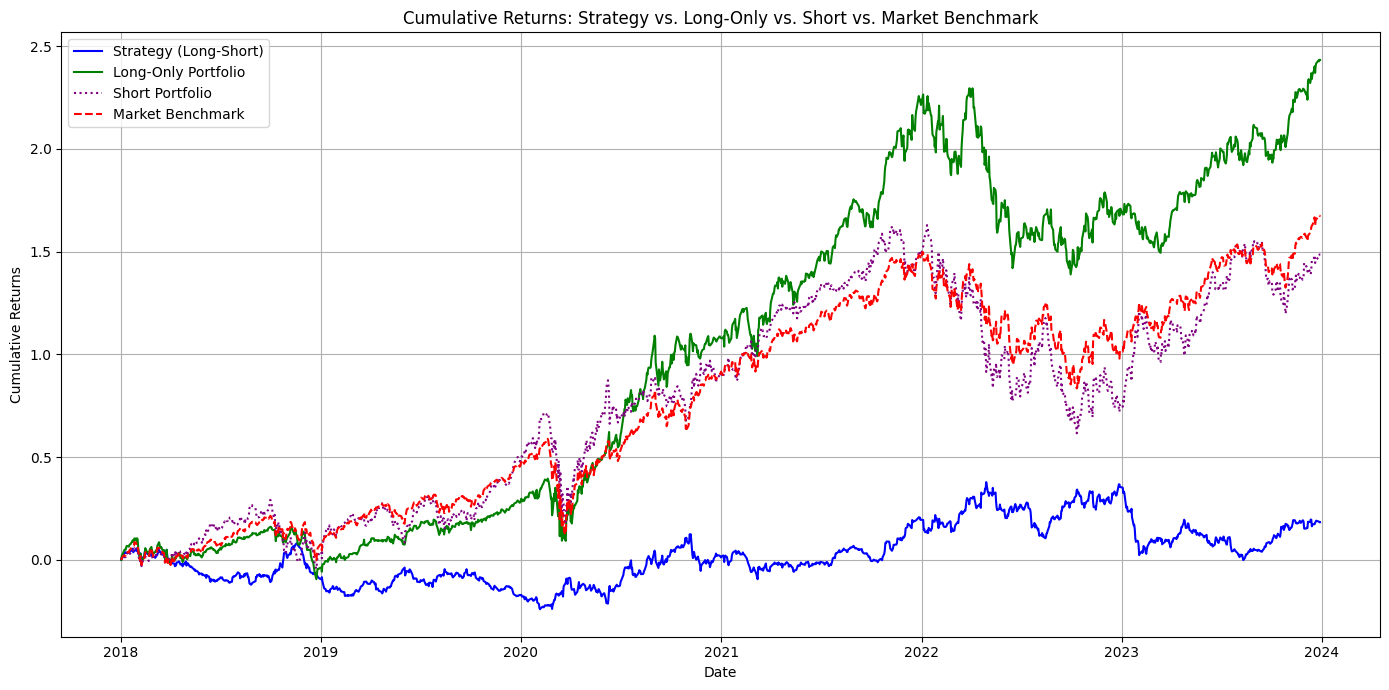

In [ ]:
# @title 14.1 Plot Cumulative Returns

print("\n--- Visualizing Cumulative Returns ---\n")

plt.figure(figsize=(14, 7))
plt.plot(backtest_results['Strategy'], label='Strategy (Long-Short)', color='blue')
plt.plot(backtest_results['Long_Portfolio'], label='Long-Only Portfolio', color='green')
plt.plot(backtest_results['Short_Portfolio'], label='Short Portfolio', color='purple', linestyle=':')
plt.plot(backtest_results['Market'], label='Market Benchmark', color='red', linestyle='--')
plt.title('Cumulative Returns: Strategy vs. Long-Only vs. Short vs. Market Benchmark')
plt.xlabel('Date')
plt.ylabel('Cumulative Returns')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# @title 13.1 Calculate Performance Metrics

print("\n--- Calculating Performance Metrics ---\n")

def calculate_cagr(cumulative_returns_series, periods_per_year=252):
    """Calculates Compound Annual Growth Rate (CAGR)."""
    if cumulative_returns_series.empty:
        return np.nan
    total_return = cumulative_returns_series.iloc[-1]
    num_years = len(cumulative_returns_series) / periods_per_year
    if num_years <= 0:
        return 0.0 # Or np.nan, depending on desired behavior for very short periods
    cagr = (1 + total_return)**(1 / num_years) - 1
    return cagr

def calculate_volatility(daily_returns_series, periods_per_year=252):
    """Calculates annualized volatility."""
    if daily_returns_series.empty:
        return np.nan
    return daily_returns_series.std() * np.sqrt(periods_per_year)

def calculate_sharpe_ratio(daily_returns_series, risk_free_rate=0.02, periods_per_year=252):
    """Calculates annualized Sharpe Ratio."""
    if daily_returns_series.empty or daily_returns_series.std() == 0:
        return np.nan
    # Convert annual risk-free rate to daily
    daily_risk_free_rate = (1 + risk_free_rate)**(1 / periods_per_year) - 1
    excess_returns = daily_returns_series - daily_risk_free_rate
    return np.sqrt(periods_per_year) * (excess_returns.mean() / excess_returns.std())

def calculate_max_drawdown(cumulative_returns_series):
    """Calculates Maximum Drawdown."""
    if cumulative_returns_series.empty:
        return np.nan
    # Add 1 to cumulative returns to get total wealth series
    wealth_series = (1 + cumulative_returns_series.fillna(0))
    if wealth_series.empty or wealth_series.iloc[0] <= 0:
      return 0.0
    peak = wealth_series.expanding(min_periods=1).max()
    drawdown = (wealth_series / peak) - 1
    return drawdown.min()

# Prepare daily returns for metrics calculation
# Note: backtest_results contains cumulative returns, we need daily for some metrics
# We'll use the 'strategy_daily_returns' and 'long_portfolio_daily_returns' from the backtester, and create market_daily_returns

# Ensure these series are available from the previous backtest step
# strategy_daily_returns
# long_portfolio_daily_returns
# market_daily_returns (already calculated in backtest section)

portfolio_metrics = pd.DataFrame(index=['Strategy', 'Long_Only', 'Market'],
                                 columns=['CAGR', 'Volatility', 'Sharpe_Ratio', 'Max_Drawdown'])

# Strategy Metrics
portfolio_metrics.loc['Strategy', 'CAGR'] = calculate_cagr(backtest_results['Strategy'])
portfolio_metrics.loc['Strategy', 'Volatility'] = calculate_volatility(strategy_daily_returns)
portfolio_metrics.loc['Strategy', 'Sharpe_Ratio'] = calculate_sharpe_ratio(strategy_daily_returns)
portfolio_metrics.loc['Strategy', 'Max_Drawdown'] = calculate_max_drawdown(backtest_results['Strategy'])

# Long-Only Portfolio Metrics
portfolio_metrics.loc['Long_Only', 'CAGR'] = calculate_cagr(backtest_results['Long_Portfolio'])
portfolio_metrics.loc['Long_Only', 'Volatility'] = calculate_volatility(long_portfolio_daily_returns)
portfolio_metrics.loc['Long_Only', 'Sharpe_Ratio'] = calculate_sharpe_ratio(long_portfolio_daily_returns)
portfolio_metrics.loc['Long_Only', 'Max_Drawdown'] = calculate_max_drawdown(backtest_results['Long_Portfolio'])

# Market Metrics
portfolio_metrics.loc['Market', 'CAGR'] = calculate_cagr(backtest_results['Market'])
portfolio_metrics.loc['Market', 'Volatility'] = calculate_volatility(market_daily_returns)
portfolio_metrics.loc['Market', 'Sharpe_Ratio'] = calculate_sharpe_ratio(market_daily_returns)
portfolio_metrics.loc['Market', 'Max_Drawdown'] = calculate_max_drawdown(backtest_results['Market'])

print("\n--- Performance Summary ---\n")
print(portfolio_metrics.round(4))

# Store performance metrics for future reference
performance_summary_df = portfolio_metrics

print("\nPerformance metrics calculation complete!")


--- Calculating Performance Metrics ---


--- Performance Summary ---

               CAGR Volatility Sharpe_Ratio Max_Drawdown
Strategy   0.028505   0.189367     0.138666    -0.297555
Long_Only  0.228741   0.230074      0.92478    -0.274902
Market      0.17823   0.208844     0.796078    -0.293168

Performance metrics calculation complete!


In [ ]:
# @title 14.2 Display Performance Summary Table

print("\n--- Performance Summary Table ---\n")

display(performance_summary_df.round(4))


--- Performance Summary Table ---



,CAGR,Volatility,Sharpe_Ratio,Max_Drawdown
Strategy,0.028505,0.189367,0.138666,-0.297555
Long_Only,0.228741,0.230074,0.92478,-0.274902
Market,0.17823,0.208844,0.796078,-0.293168
